# Classification

## Binary

In [555]:
from sklearn.datasets import make_circles

In [556]:
n_samples = 1000
_X, _y = make_circles(n_samples,noise=0.03,random_state=42)
_X[:5], _y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [557]:
import pandas as pd

In [558]:
circles = pd.DataFrame({"X1": _X[:,0],"X2": _X[:,1],"label":_y})

In [559]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [560]:
circles.label.value_counts()

,count
label,
1,500
0,500


In [561]:
import matplotlib.pyplot as plt

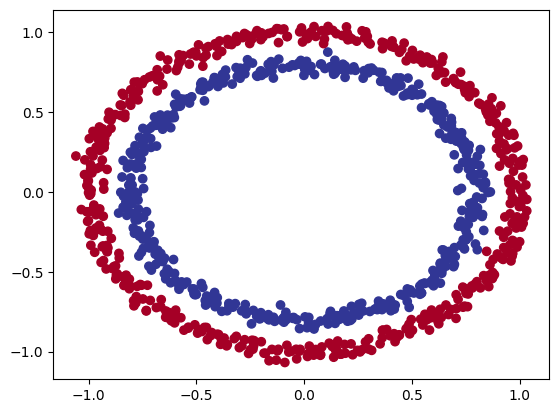

In [562]:
plt.scatter(_X[:,0],_X[:,1],c=_y,cmap=plt.cm.RdYlBu)

In [563]:
_X.shape, _y.shape

((1000, 2), (1000,))

In [564]:
import torch

In [565]:
def accuracy_fn(y_true,y_pred):
  if len(y_pred) == 0:
    return 0
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = correct / len(y_pred) * 100
  return acc

In [624]:
def train_model(model,epochs,X_train,y_train,X_test,y_test):
  torch.manual_seed(42) # CPU (and CUDA on recent versions)

  for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # loss = loss_fn(torch.sigmoid(y_logits),y_train) # BCELoss
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_train,y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
      test_logits = model(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))

      test_loss = loss_fn(test_logits,y_test)
      test_acc = accuracy_fn(y_test,test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} Loss: {loss:.5f} Acc: {acc:.2f} Test loss: {test_loss:.5f} Test acc: {test_acc:.2f}")

  print(f"Epoch: {epoch} Loss: {loss:.5f} Acc: {acc:.2f} Test loss: {test_loss:.5f} Test acc: {test_acc:.2f}")

In [567]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [568]:
X = torch.from_numpy(_X).type(torch.float).to(device)
y = torch.from_numpy(_y).type(torch.float).to(device)

In [569]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [570]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [571]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [572]:
from torch import nn

In [573]:
X_train.shape # 800 samples, 2 features (in_features=2)

torch.Size([800, 2])

In [574]:
y_train.shape # 800 labels (out_features=1)

torch.Size([800])

In [575]:
class ClassifierModel(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.layer_1 = nn.Linear(in_features=2,out_features=5)
    self.layer_2 = nn.Linear(in_features=5,out_features=1)

  def forward(self,x) -> torch.Tensor:
    return self.layer_2(self.layer_1(x))

In [576]:
model = ClassifierModel().to(device)
model

ClassifierModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [577]:
class ClassifierModel(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.layers = nn.Sequential(
      nn.Linear(in_features=2,out_features=5),
      nn.Linear(in_features=5,out_features=1)
    )

  def forward(self,x) -> torch.Tensor:
    return self.layers(x)

In [578]:
model = ClassifierModel().to(device)
model

ClassifierModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [579]:
from IPython.display import IFrame
IFrame("https://playground.tensorflow.org", width=800, height=600)

In [580]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)

model

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [581]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]])),
             ('0.bias', tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410])),
             ('1.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]])),
             ('1.bias', tensor([-0.2060]))])

In [582]:
# logit: raw, unnormalized output of a model's final layer, before any activation is applied
model.eval()
with torch.inference_mode():
  y_logits = model(X_test)

In [583]:
y_logits.shape

torch.Size([200, 1])

In [584]:
loss_fn = nn.Sequential(
  nn.Sigmoid(),
  nn.BCELoss() # requires the inputs to have gone through an activation function
)

In [585]:
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function built-in (numerical stability)

In [586]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [587]:
# Raw logits -> Prediction probabilities -> Prediction labels

In [588]:
y_logits[:5]

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]])

In [589]:
y_probs = torch.sigmoid(y_logits)
y_probs[:5]

tensor([[0.4683],
        [0.4758],
        [0.4524],
        [0.4728],
        [0.4584]])

In [590]:
y_labels = torch.round(y_probs)
y_labels[:5]

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [591]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [592]:
accuracy_fn(y_test,y_labels.squeeze())

50.0

In [593]:
train_model(model,100,X_train,y_train,X_test,y_test)

Epoch: 0 Loss: 0.69569 Acc: 50.00 Test loss: 0.69721 Test acc: 50.00
Epoch: 10 Loss: 0.69403 Acc: 50.00 Test loss: 0.69615 Test acc: 50.00
Epoch: 20 Loss: 0.69343 Acc: 46.00 Test loss: 0.69585 Test acc: 48.50
Epoch: 30 Loss: 0.69321 Acc: 49.00 Test loss: 0.69577 Test acc: 47.50
Epoch: 40 Loss: 0.69312 Acc: 49.50 Test loss: 0.69573 Test acc: 46.50
Epoch: 50 Loss: 0.69308 Acc: 50.38 Test loss: 0.69569 Test acc: 46.50
Epoch: 60 Loss: 0.69306 Acc: 50.50 Test loss: 0.69564 Test acc: 46.50
Epoch: 70 Loss: 0.69305 Acc: 50.50 Test loss: 0.69559 Test acc: 46.50
Epoch: 80 Loss: 0.69304 Acc: 50.75 Test loss: 0.69553 Test acc: 46.50
Epoch: 90 Loss: 0.69303 Acc: 50.38 Test loss: 0.69547 Test acc: 46.50


In [594]:
import numpy as np

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

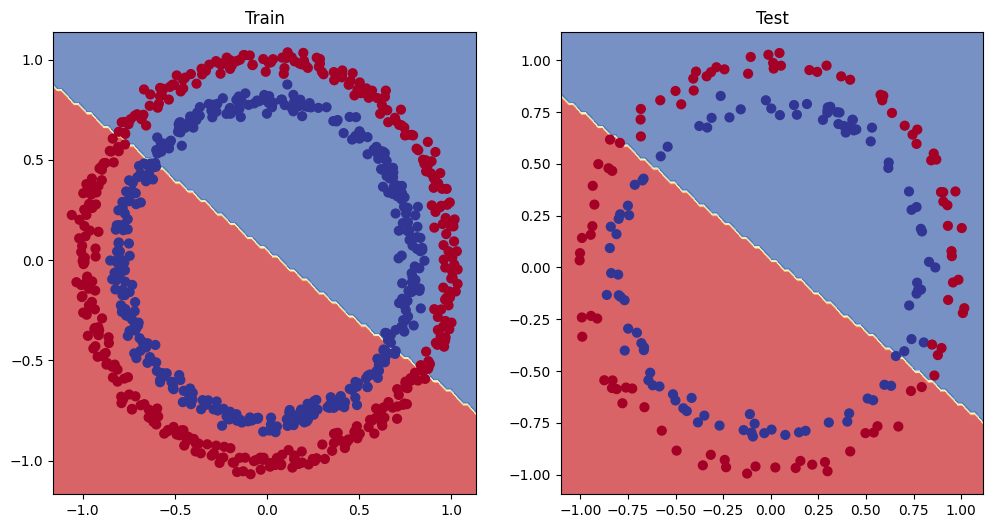

In [595]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

## Improve the model (from the model perspective)

* Add more layers
* Add more hidden units
* Fitting for longer (more epochs)
* Changing the activation functions
* Change the learning rate
* Change the loss function
* Use transfer learning

In [596]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(in_features=2,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [597]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [598]:
train_model(model,250,X_train,y_train,X_test,y_test)

Epoch: 0 Loss: 0.69396 Acc: 50.88 Test loss: 0.69261 Test acc: 51.00
Epoch: 10 Loss: 0.69369 Acc: 50.25 Test loss: 0.69270 Test acc: 50.00
Epoch: 20 Loss: 0.69351 Acc: 50.12 Test loss: 0.69283 Test acc: 49.50
Epoch: 30 Loss: 0.69339 Acc: 50.50 Test loss: 0.69297 Test acc: 48.00
Epoch: 40 Loss: 0.69329 Acc: 50.38 Test loss: 0.69310 Test acc: 49.00
Epoch: 50 Loss: 0.69322 Acc: 49.88 Test loss: 0.69324 Test acc: 50.00
Epoch: 60 Loss: 0.69317 Acc: 49.38 Test loss: 0.69336 Test acc: 51.50
Epoch: 70 Loss: 0.69312 Acc: 49.38 Test loss: 0.69348 Test acc: 50.50
Epoch: 80 Loss: 0.69309 Acc: 50.12 Test loss: 0.69359 Test acc: 50.00
Epoch: 90 Loss: 0.69307 Acc: 50.50 Test loss: 0.69370 Test acc: 48.50
Epoch: 100 Loss: 0.69305 Acc: 50.38 Test loss: 0.69379 Test acc: 48.00
Epoch: 110 Loss: 0.69303 Acc: 50.88 Test loss: 0.69388 Test acc: 46.50
Epoch: 120 Loss: 0.69302 Acc: 50.75 Test loss: 0.69396 Test acc: 46.50
Epoch: 130 Loss: 0.69301 Acc: 50.62 Test loss: 0.69403 Test acc: 46.00
Epoch: 140 Loss: 

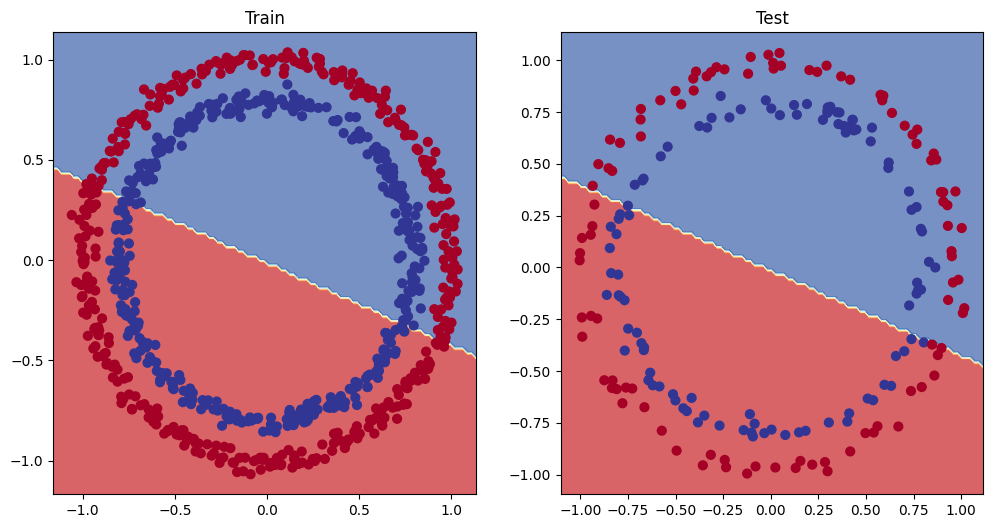

In [599]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

## Can the model learn anything at all?

In [600]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_r = torch.arange(start,end,step).unsqueeze(1)
y_r = weight * X_r + bias

X_r[:5], y_r[:5]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [601]:
train_split = int(0.8 * len(X_r))
X_train_r, y_train_r = X_r[:train_split], y_r[:train_split]
X_test_r, y_test_r = X_r[train_split:], y_r[train_split:]

In [602]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(in_features=1,out_features=10), # adapt in_features
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [603]:
loss_fn = nn.L1Loss()

In [604]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [605]:
torch.manual_seed(42)
epochs = 41
for epoch in range(epochs):
  model.train()
  y_pred = model(X_train_r)
  loss = loss_fn(y_pred,y_train_r)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_pred = model(X_test_r)
    test_loss = loss_fn(test_pred,y_test_r)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} Loss: {loss:.5f} Test loss: {test_loss:.5f}")

Epoch: 0 Loss: 0.75986 Test loss: 0.54143
Epoch: 10 Loss: 0.14550 Test loss: 0.02363
Epoch: 20 Loss: 0.14420 Test loss: 0.05597
Epoch: 30 Loss: 0.10136 Test loss: 0.03785
Epoch: 40 Loss: 0.07525 Test loss: 0.00984


In [606]:
def plot_preds(train_data,train_labels,test_data,test_labels,preds=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")
  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")
  if preds is not None:
    plt.scatter(test_data,preds,c="r",s=4,label="Predictions")
  plt.legend()

In [607]:
model.eval()
with torch.inference_mode():
  y_pred = model(X_test_r)
y_pred[:5]

tensor([[0.8828],
        [0.8882],
        [0.8937],
        [0.8991],
        [0.9046]])

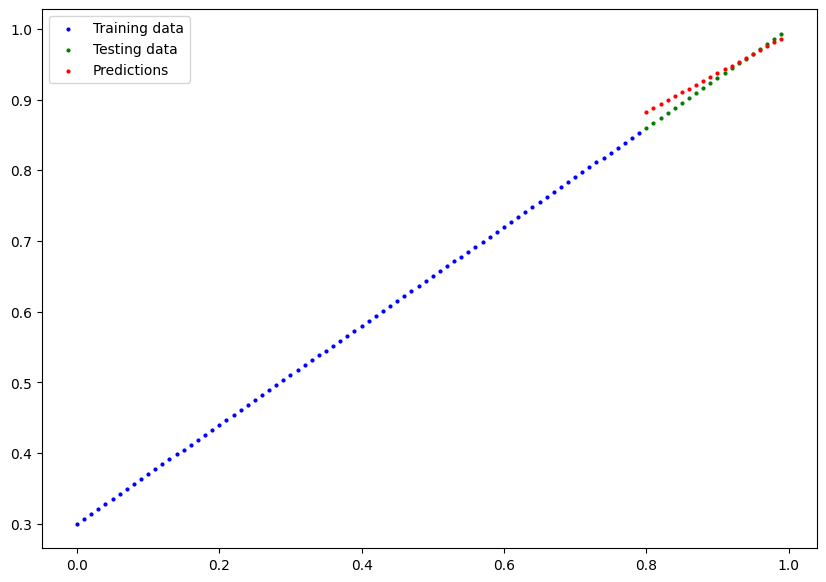

In [608]:
plot_preds(X_train_r,y_train_r,X_test_r,y_test_r,y_pred)

## Nonlinearity

In [625]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(in_features=2,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10,out_features=1)
).to(device)

model

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)

In [626]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [627]:
loss_fn = nn.BCEWithLogitsLoss()

In [628]:
train_model(model,2000,X_train,y_train,X_test,y_test)

Epoch: 0 Loss: 0.69295 Acc: 50.00 Test loss: 0.69319 Test acc: 50.00
Epoch: 10 Loss: 0.69248 Acc: 50.50 Test loss: 0.69260 Test acc: 50.00
Epoch: 20 Loss: 0.69225 Acc: 59.13 Test loss: 0.69231 Test acc: 56.50
Epoch: 30 Loss: 0.69209 Acc: 70.25 Test loss: 0.69212 Test acc: 68.00
Epoch: 40 Loss: 0.69195 Acc: 68.38 Test loss: 0.69195 Test acc: 71.00
Epoch: 50 Loss: 0.69181 Acc: 58.25 Test loss: 0.69177 Test acc: 58.00
Epoch: 60 Loss: 0.69168 Acc: 54.00 Test loss: 0.69161 Test acc: 54.50
Epoch: 70 Loss: 0.69155 Acc: 53.12 Test loss: 0.69146 Test acc: 53.00
Epoch: 80 Loss: 0.69141 Acc: 52.62 Test loss: 0.69132 Test acc: 53.00
Epoch: 90 Loss: 0.69128 Acc: 52.75 Test loss: 0.69117 Test acc: 53.00
Epoch: 100 Loss: 0.69115 Acc: 52.88 Test loss: 0.69102 Test acc: 52.50
Epoch: 110 Loss: 0.69103 Acc: 52.88 Test loss: 0.69088 Test acc: 53.50
Epoch: 120 Loss: 0.69090 Acc: 53.12 Test loss: 0.69074 Test acc: 54.00
Epoch: 130 Loss: 0.69077 Acc: 53.00 Test loss: 0.69058 Test acc: 54.50
Epoch: 140 Loss: 

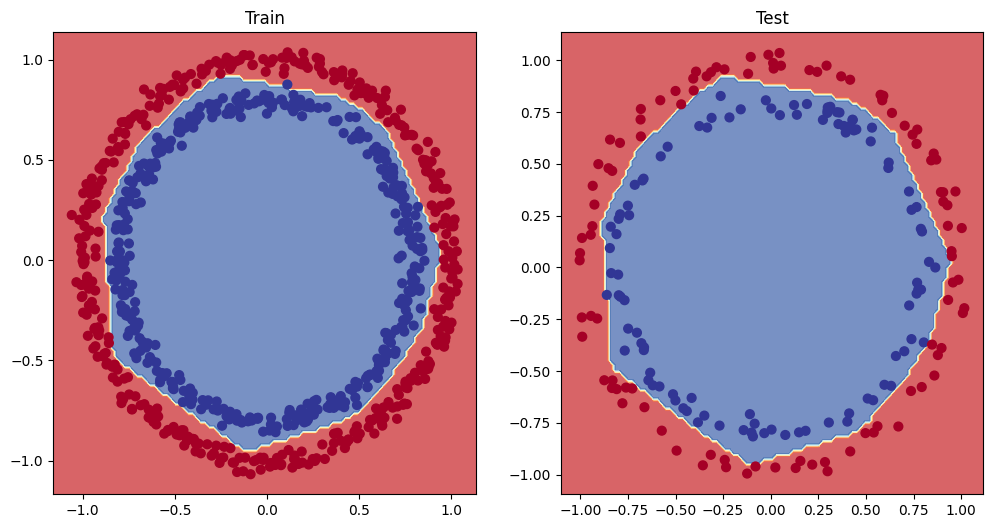

In [622]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

## ReLU

In [629]:
A = torch.arange(-10,10,1,dtype=torch.float)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

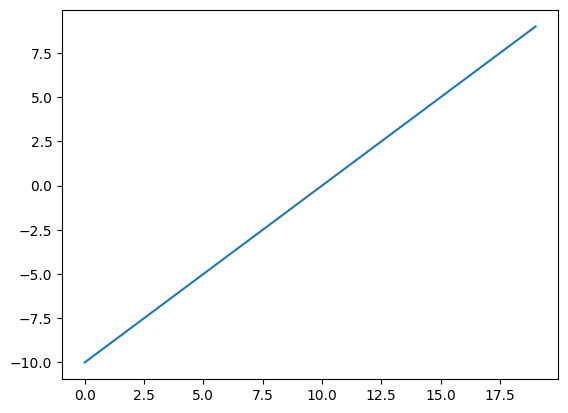

In [630]:
plt.plot(A)

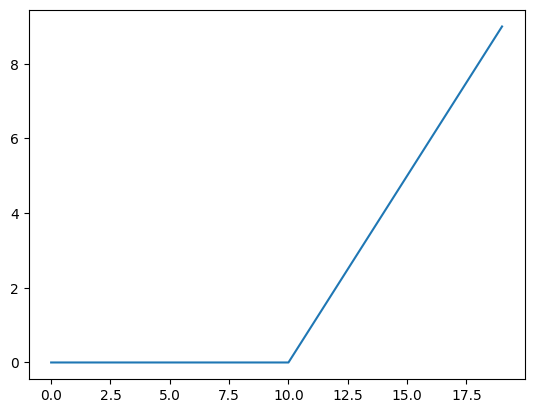

In [631]:
plt.plot(torch.relu(A))

In [634]:
def relu(x:torch.Tensor)->torch.Tensor:
  return torch.max(torch.tensor(0),x)

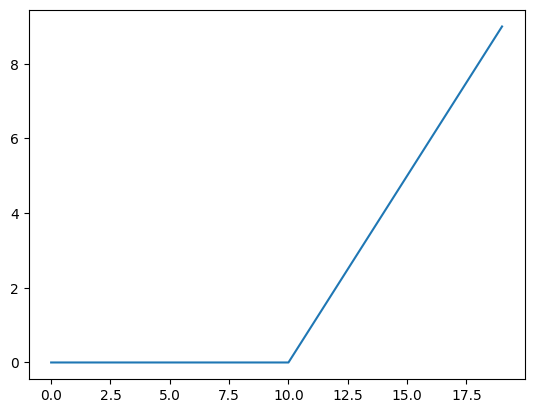

In [635]:
plt.plot(relu(A))

In [636]:
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

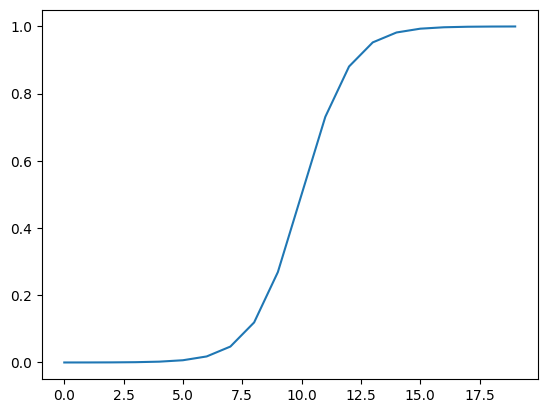

In [637]:
plt.plot(sigmoid(A))

## Multi-class

In [669]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [670]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [671]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

In [672]:
_X, _y = make_blobs(1000,NUM_FEATURES,centers=NUM_CLASSES,cluster_std=1.5,random_state=RANDOM_SEED)

In [681]:
X = torch.from_numpy(_X).type(torch.float).to(device)
y = torch.from_numpy(_y).type(torch.long).to(device)

In [682]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED)

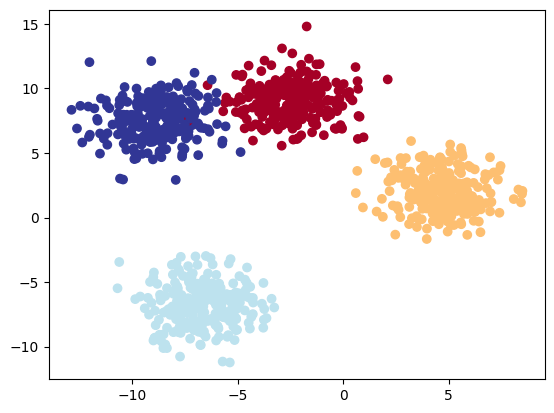

In [683]:
plt.scatter(_X[:,0],_X[:,1],c=_y,cmap=plt.cm.RdYlBu)

In [690]:
torch.manual_seed(42)

class ClassifierModel(nn.Module):
  def __init__(self, in_features, out_features, hidden_units=8) -> None:
    super().__init__()
    self.layers = nn.Sequential(
      nn.Linear(in_features=in_features,out_features=hidden_units),
      # nn.ReLU(),
      nn.Linear(in_features=hidden_units,out_features=hidden_units),
      # nn.ReLU(),
      nn.Linear(in_features=hidden_units,out_features=out_features)
    )

  def forward(self,x) -> torch.Tensor:
    return self.layers(x)

model = ClassifierModel(NUM_FEATURES,NUM_CLASSES,8).to(device)

optimizer = torch.optim.SGD(model.parameters(),lr=0.03)
loss_fn = nn.CrossEntropyLoss()

model

ClassifierModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [691]:
model.eval()
with torch.inference_mode():
  y_logits = model(X_test)
y_logits[:5]

tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]])

In [692]:
y_probs = torch.softmax(y_logits,dim=1)
y_probs[:5]

tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]])

In [693]:
y_pred = torch.argmax(y_probs,dim=1)
y_pred[:5]

tensor([3, 3, 2, 1, 3])

In [694]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
  model.train()

  y_logits = model(X_train).squeeze()
  y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_test,test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} Loss: {loss:.5f} Acc: {acc:.2f} Test loss: {test_loss:.5f} Test acc: {test_acc:.2f}")

print(f"Epoch: {epoch} Loss: {loss:.5f} Acc: {acc:.2f} Test loss: {test_loss:.5f} Test acc: {test_acc:.2f}")

Epoch: 0 Loss: 1.04324 Acc: 65.50 Test loss: 0.84741 Test acc: 73.50
Epoch: 10 Loss: 0.36746 Acc: 98.50 Test loss: 0.34806 Test acc: 99.00
Epoch: 20 Loss: 0.22773 Acc: 98.88 Test loss: 0.21969 Test acc: 99.50
Epoch: 30 Loss: 0.16385 Acc: 99.12 Test loss: 0.15795 Test acc: 99.00
Epoch: 40 Loss: 0.12793 Acc: 99.12 Test loss: 0.12235 Test acc: 99.00
Epoch: 50 Loss: 0.10540 Acc: 99.12 Test loss: 0.09968 Test acc: 99.00
Epoch: 60 Loss: 0.09019 Acc: 99.12 Test loss: 0.08423 Test acc: 99.50
Epoch: 70 Loss: 0.07935 Acc: 99.12 Test loss: 0.07313 Test acc: 99.50
Epoch: 80 Loss: 0.07128 Acc: 99.12 Test loss: 0.06483 Test acc: 99.50
Epoch: 90 Loss: 0.06509 Acc: 99.12 Test loss: 0.05842 Test acc: 99.50
Epoch: 99 Loss: 0.06064 Acc: 99.12 Test loss: 0.05380 Test acc: 99.50


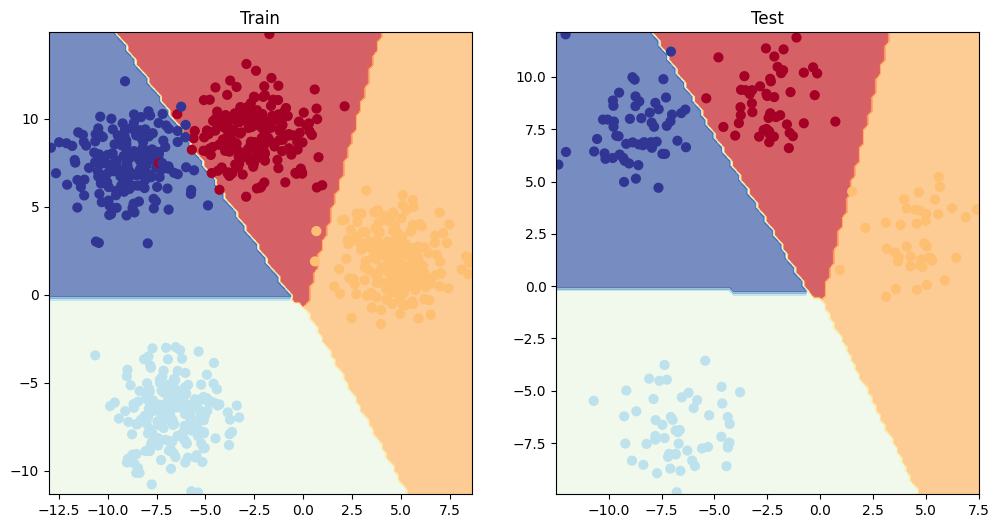

In [695]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

## Metrics

* Accuracy
* Precision
* Recall
* F1 score
* Confusion matrix
* Classification report

In [696]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.9 MB/s eta 0:00:00


In [707]:
from torchmetrics import Accuracy, F1Score

In [703]:
model.eval()
with torch.inference_mode():
  y_logits = model(X_test).squeeze()
  y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)

In [706]:
accuracy_fn = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)
accuracy_fn(y_pred,y_test)

tensor(0.9950)

In [709]:
f1_score_fn = F1Score(task="multiclass", num_classes=NUM_CLASSES).to(device)
f1_score_fn(y_pred,y_test)

tensor(0.9950)

In [710]:
92

92